In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky, inv
from numpy.linalg import LinAlgError

In [2]:
# Константы
g = 9.81
dt = 0.02
window_size = 50
var_threshold_accel = 25
delta_intervals = 5

In [3]:
# Загрузка данных
df = pd.read_csv('INS-MEMS3.LOG', header=None, skiprows=1, delim_whitespace=True)
df.columns = ['ID', 'MAG1', 'MAG2', 'MAG3', 'ACS1', 'ACS2', 'AKS3', 'GYRO1', 'GYRO2', 'GYRO3', 'HH', 'MM', 'SS', 'MS']

df['time_sec'] = df['HH'] * 3600 + df['MM'] * 60 + df['SS'] + df['MS'] / 1000
df['accel_magnitude'] = np.linalg.norm(df[['ACS1', 'ACS2', 'AKS3']].values, axis=1)

C:\Users\arefe\AppData\Local\Temp\ipykernel_19512\1970005143.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('INS-MEMS3.LOG', header=None, skiprows=1, delim_whitespace=True)


In [ ]:
# Участки покоя
df['stationary'] = False
AKS = df[['ACS1', 'ACS2', 'AKS3']].values
for i in range(len(df) - window_size + 1):
    accel_window = AKS[i:i + window_size]
    if np.all(np.var(accel_window, axis=0) < var_threshold_accel):
        df.loc[i:i + window_size - 1, 'stationary'] = True

# Проверка количества участков покоя
stationary_diff = np.diff(np.concatenate([[False], df['stationary'].values, [False]]))
start_stat_idx = np.where(stationary_diff == True)[0]
end_stat_idx = np.where(stationary_diff == False)[0] - 1

if len(start_stat_idx) < 18:
    raise ValueError(f"Найдено {len(start_stat_idx)} участков покоя, требуется 18.")

start_idx_stationary = start_stat_idx[:18]
end_idx_stationary = end_stat_idx[:18]

In [5]:
# Средние значения
A_data = np.array([
    df.iloc[s:e + 1][['ACS1', 'ACS2', 'AKS3']].mean().values
    for s, e in zip(start_idx_stationary, end_idx_stationary)
])

n_points = A_data.shape[0]
H = np.zeros((n_points, 9))
y = np.ones(n_points)
for i in range(n_points):
    ax, ay, az = A_data[i]
    H[i, :] = [ax**2, ay**2, az**2, 2*ax*ay, 2*ax*az, 2*ay*az, 2*ax, 2*ay, 2*az]

In [6]:
# МНК
x = np.linalg.lstsq(H, y, rcond=None)[0]
M_tilde = np.array([[x[0], x[3], x[4]],
                    [x[3], x[1], x[5]],
                    [x[4], x[5], x[2]]])
m_tilde = x[6:9]

In [ ]:
# Регуляризация, если M_tilde вырожденная !!!
eps = 1e-6
try:
    const = g**2 / (1 + m_tilde @ inv(M_tilde) @ m_tilde)
except LinAlgError:
    print("Предупреждение: матрица M_tilde вырождена. Добавляется регуляризация.")
    M_tilde += np.eye(3) * eps
    const = g**2 / (1 + m_tilde @ inv(M_tilde) @ m_tilde)

M = const * M_tilde
m = const * m_tilde
c = g**2 * m_tilde @ inv(M_tilde) @ m_tilde / (1 + m_tilde @ inv(M_tilde) @ m_tilde)

Предупреждение: матрица M_tilde вырождена. Добавляется регуляризация.


In [8]:
# Холецкий
try:
    S_f_upper = cholesky(M, lower=False)
except LinAlgError:
    raise ValueError("Матрица M не является положительно определённой.")

S_f = S_f_upper.T
b_f = inv(S_f.T) @ m

In [9]:
# Калибровка данных
AKS_matrix = df[['ACS1', 'ACS2', 'AKS3']].values.T
b_f_matrix = np.tile(b_f.reshape(-1, 1), (1, AKS_matrix.shape[1]))
f_z = (S_f @ AKS_matrix + b_f_matrix).T
df[['fx', 'fy', 'fz']] = f_z

In [10]:
# Вывод
print("S_f =\n", S_f)
print("b_f =\n", b_f)

f_z_magnitude = np.linalg.norm(f_z, axis=1)
print("Среднее ускорение на участках покоя: {:.2f} м/с²".format(f_z_magnitude[df['stationary']].mean()))

S_f =
 [[0.00981 0.      0.     ]
 [0.      0.00981 0.     ]
 [0.      0.      0.00981]]
b_f =
 [0. 0. 0.]
Среднее ускорение на участках покоя: 9.22 м/с²


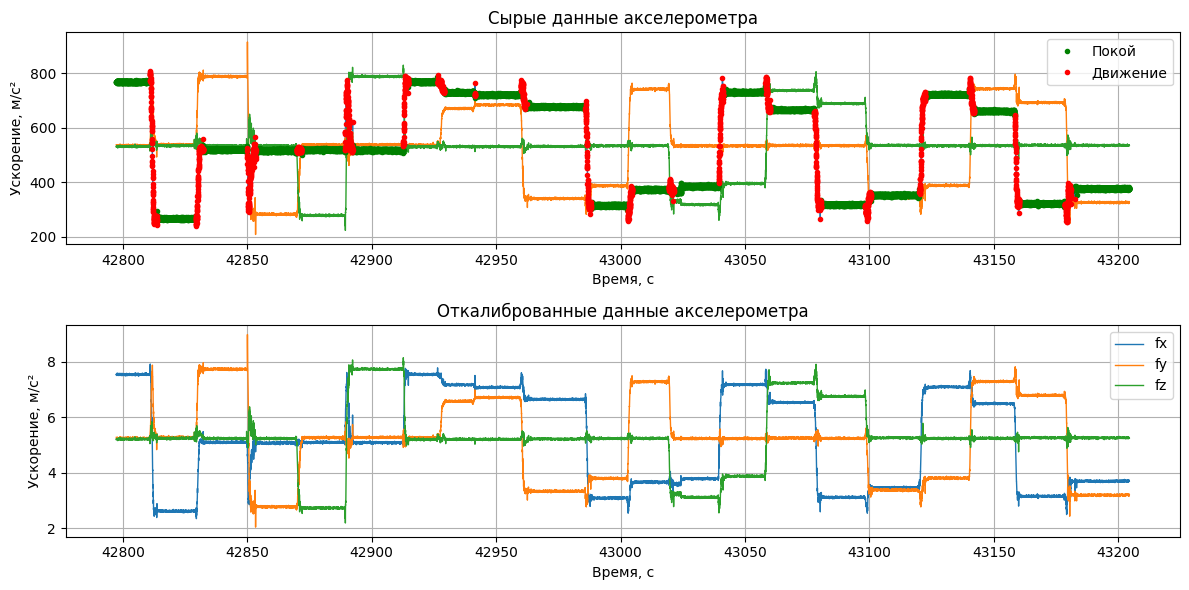

In [11]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(df['time_sec'], df[['ACS1', 'ACS2', 'AKS3']], linewidth=1)
plt.plot(df.loc[df['stationary'], 'time_sec'], df.loc[df['stationary'], 'ACS1'], 'g.', markersize=6, label='Покой')
plt.plot(df.loc[~df['stationary'], 'time_sec'], df.loc[~df['stationary'], 'ACS1'], 'r.', markersize=6, label='Движение')
plt.title('Сырые данные акселерометра')
plt.xlabel('Время, с')
plt.ylabel('Ускорение, м/с²')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(df['time_sec'], df[['fx', 'fy', 'fz']], linewidth=1)
plt.title('Откалиброванные данные акселерометра')
plt.xlabel('Время, с')
plt.ylabel('Ускорение, м/с²')
plt.legend(['fx', 'fy', 'fz'])
plt.grid()
plt.tight_layout()
plt.savefig('calibration_with_stationary_plot.png')
plt.show()

In [12]:
# Сохранение результатов
df[['time_sec', 'ACS1', 'ACS2', 'AKS3', 'stationary']].to_csv('stationary_motion.txt', sep='\t', index=False, float_format='%.6f')